In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  


from src import colour_palettes_support as pal
from src import soporte_correlacion as sp_corr

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))  
sys.path.append(os.path.abspath('.'))

from pathlib import Path

## Load

In [6]:
BASE_DIR = Path().resolve().parent  
df_customer_clean = pd.read_csv(BASE_DIR / "data" / "Clean" / "Customer Flight Profile_clean.csv")

pd.set_option("display.max_columns", None)

## Visualización y estadística descriptiva: análisis insights sobre CSV limpio

In [7]:
df_customer_clean.head(2)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0,0,2017,1,0,0,0,0,0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0,0,2017,2,3,0,3,2823,282,0,0


In [8]:
df_customer_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Country                      405624 non-null  object 
 2   Province                     405624 non-null  object 
 3   City                         405624 non-null  object 
 4   Postal Code                  405624 non-null  object 
 5   Gender                       405624 non-null  object 
 6   Education                    405624 non-null  object 
 7   Salary                       405624 non-null  float64
 8   Marital Status               405624 non-null  object 
 9   Loyalty Card                 405624 non-null  object 
 10  CLV                          405624 non-null  float64
 11  Enrollment Type              405624 non-null  object 
 12  Enrollment Year              405624 non-null  int64  
 13 

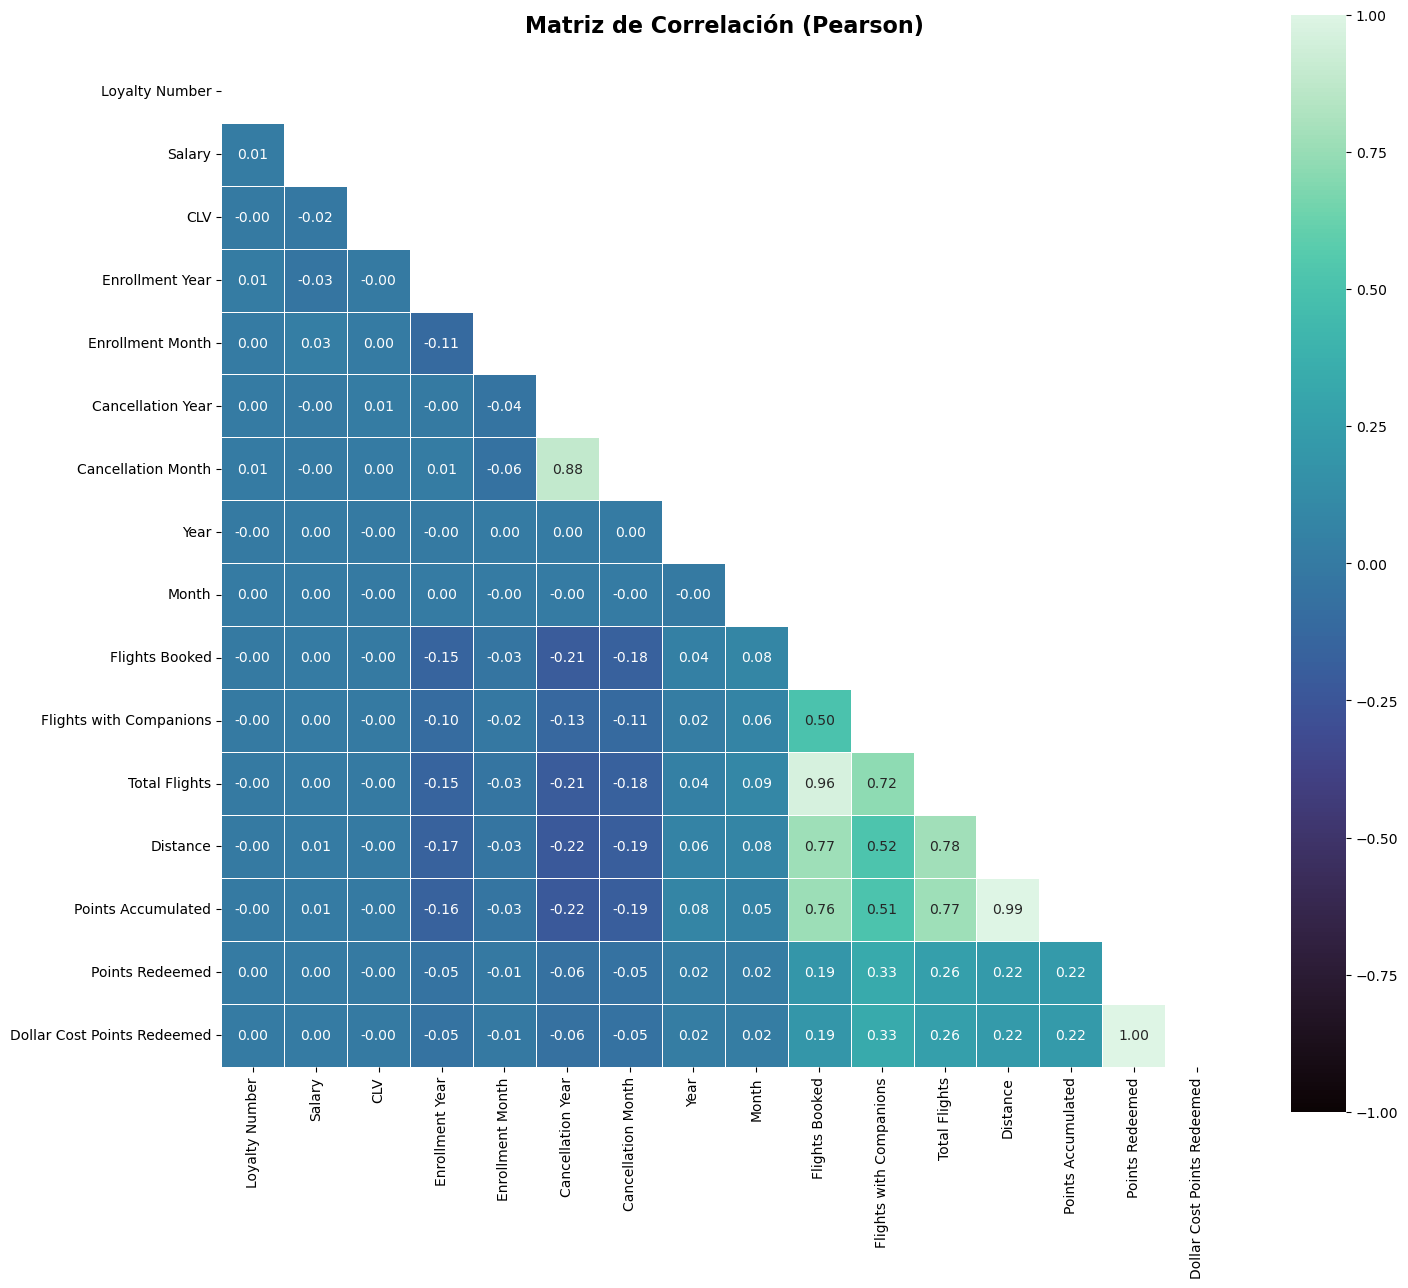

,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
Loyalty Number,1.000000e+00,1.284789e-02,-1.072427e-03,8.360517e-03,4.673399e-03,1.095772e-03,6.348212e-03,-1.623692e-13,5.900782e-17,-0.002766,-0.003373,-0.003290,-0.002302,-0.002316,0.000492,0.000486
Salary,1.284789e-02,1.000000e+00,-1.589324e-02,-3.477209e-02,2.863425e-02,-6.021844e-04,-2.037569e-03,1.143216e-13,6.975669e-17,0.004522,0.001755,0.004182,0.006626,0.006530,0.002134,0.002128
CLV,-1.072427e-03,-1.589324e-02,1.000000e+00,-1.691435e-03,2.678426e-03,9.080694e-03,3.920399e-03,-2.761286e-13,-1.395836e-15,-0.002964,-0.002583,-0.003197,-0.004252,-0.001075,-0.000304,-0.000277
Enrollment Year,8.360517e-03,-3.477209e-02,-1.691435e-03,1.000000e+00,-1.140448e-01,-3.758120e-03,1.291912e-02,-1.060526e-13,9.867125e-17,-0.153455,-0.097012,-0.153861,-0.165263,-0.164644,-0.047867,-0.047915
Enrollment Month,4.673399e-03,2.863425e-02,2.678426e-03,-1.140448e-01,1.000000e+00,-3.921739e-02,-6.246795e-02,5.550483e-14,-4.490384e-17,-0.031528,-0.019644,-0.031520,-0.034416,-0.033893,-0.008689,-0.008692
Cancellation Year,1.095772e-03,-6.021844e-04,9.080694e-03,-3.758120e-03,-3.921739e-02,1.000000e+00,8.840276e-01,7.833421e-14,-4.594961e-17,-0.207510,-0.131143,-0.208046,-0.224191,-0.224156,-0.064817,-0.064863
Cancellation Month,6.348212e-03,-2.037569e-03,3.920399e-03,1.291912e-02,-6.246795e-02,8.840276e-01,1.000000e+00,6.634896e-14,-4.998968e-17,-0.176588,-0.111210,-0.176920,-0.190711,-0.190765,-0.054953,-0.054996
Year,-1.623692e-13,1.143216e-13,-2.761286e-13,-1.060526e-13,5.550483e-14,7.833421e-14,6.634896e-14,1.000000e+00,-7.753668e-16,0.044510,0.021615,0.042550,0.056140,0.075208,0.017633,0.017624
Month,5.900782e-17,6.975669e-17,-1.395836e-15,9.867125e-17,-4.490384e-17,-4.594961e-17,-4.998968e-17,-7.753668e-16,1.000000e+00,0.082133,0.064492,0.086353,0.076345,0.054178,0.019408,0.019315
Flights Booked,-2.765738e-03,4.521641e-03,-2.963577e-03,-1.534545e-01,-3.152846e-02,-2.075100e-01,-1.765880e-01,4.451043e-02,8.213330e-02,1.000000,0.502500,0.961344,0.767457,0.760279,0.188232,0.188242


In [6]:
sp_corr.matriz_correlacion_visual(df_customer_clean)

### 1. How are the number of flights booked each month spread out over the year?

The line graph reveals a clear seasonal trend in flight bookings:

1. Peak High Season (July and August): July and August see the highest number of flights, which is typical of the summer holiday season.

2. Low Season (January/February): January and February record the lowest number of flights, marking the low season following the end-of-year holidays.

3. Spring Growth: There is a steady and marked increase in flight bookings from March until the summer peak, indicating the spring/summer season.

Conclusion: There is a strong seasonal pattern where flight volume is directly linked to holiday periods.

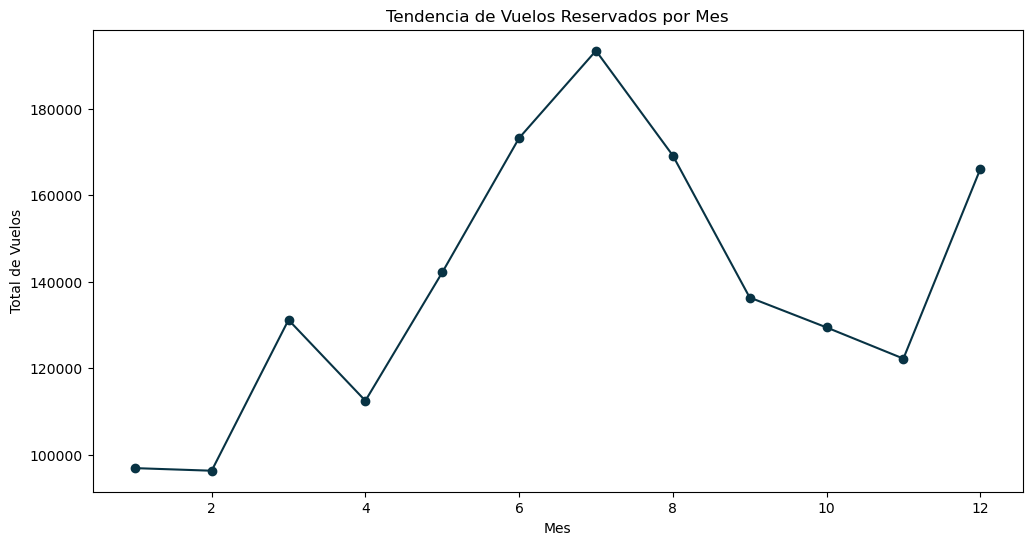

In [ ]:
plt.figure(figsize=(12, 6))

(
    df_customer_clean.groupby('Month')['Flights Booked'] 
    .sum()                                      
    .plot(kind='line', marker='o', color=pal.ocean_blue_serenity["Azul_Profundo"]) 
)

plt.title('Booked Flights Trend by Month')
plt.ylabel('total flights')
plt.xlabel('Month')
plt.show()

### Is there a link between flight distances and the points earned by customers?


1. There are strong diagonal lines. There is a positive correlation with little variation between the two variables.
2. The greater the distance flown, the higher the points accumulation (points accumulation depends directly on the miles flown).
3. There are several lines because the points accumulation system differs for each customer type (“Loyalty Card” and “Enrolment Type”).
4. Strong relationship between the type of “Loyalty Card” and points accumulation.
5. The “Enrolment Type” “2018 promotion” accumulates more points (top lines). 

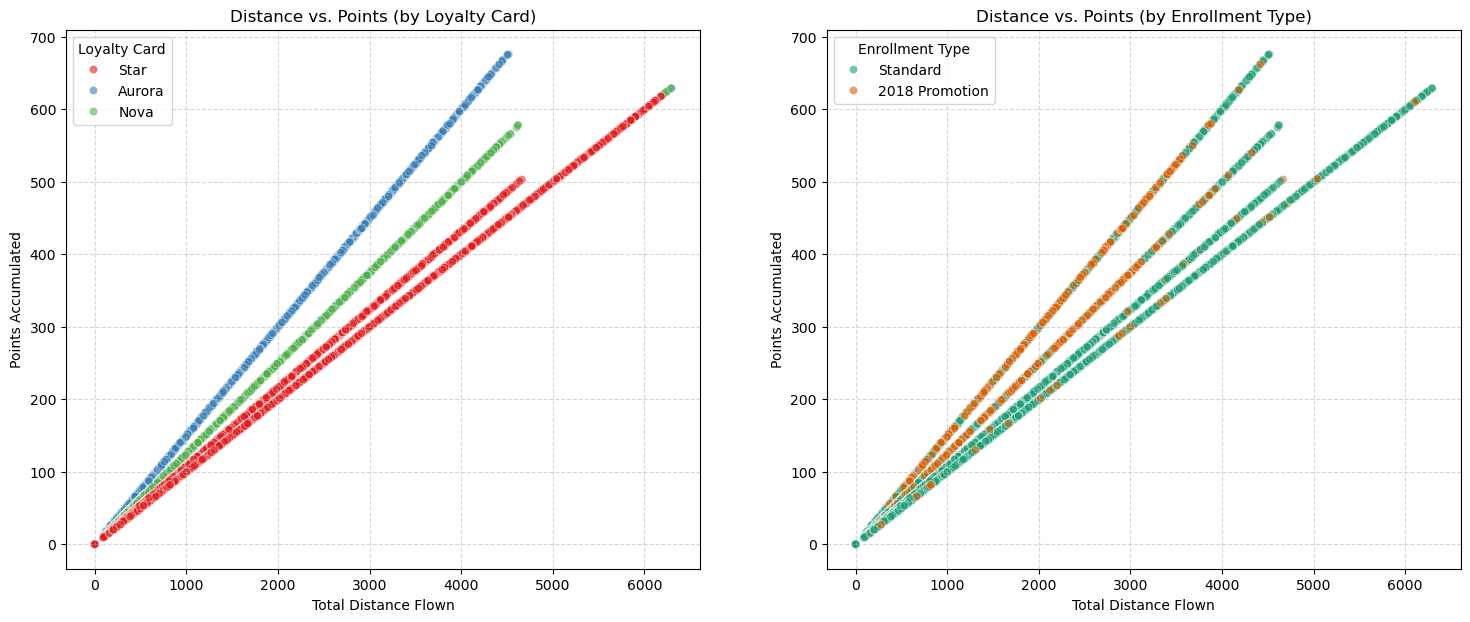

In [9]:


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7)) 

sns.scatterplot(
    data=df_customer_clean,
    x='Distance',        
    y='Points Accumulated', 
    hue='Loyalty Card',   
    alpha=0.6,           
    palette='Set1',
    ax=axes[0]             
)
axes[0].set_title('Distance vs. Points (by Loyalty Card)')
axes[0].set_xlabel('Total Distance Flown')
axes[0].set_ylabel('Points Accumulated')
axes[0].legend(title='Loyalty Card')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(
    data=df_customer_clean,
    x='Distance',        
    y='Points Accumulated', 
    hue='Enrollment Type', 
    alpha=0.6,           
    palette='Dark2',
    ax=axes[1]             
)
axes[1].set_title('Distance vs. Points (by Enrollment Type)')
axes[1].set_xlabel('Total Distance Flown')
axes[1].set_ylabel('Points Accumulated')
axes[1].legend(title='Enrollment Type')
axes[1].grid(True, linestyle='--', alpha=0.5)

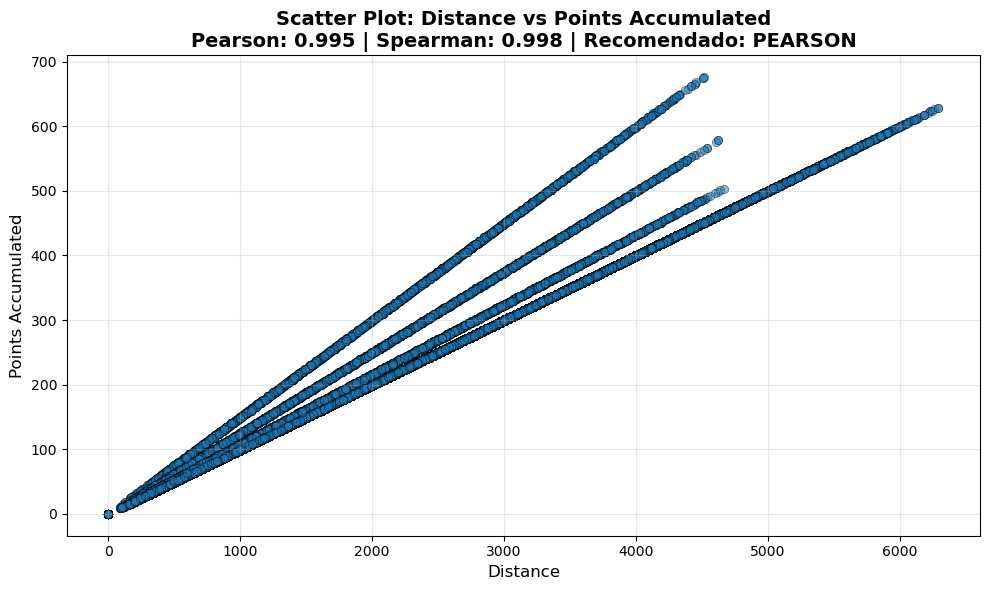

{'pearson': np.float64(0.9945635023058527),
 'spearman': np.float64(0.9980658565570554),
 'diferencia': np.float64(0.0035023542512027106),
 'recomendacion': 'pearson',
 'valor_recomendado': np.float64(0.9945635023058527),
 'fuerza': 'muy fuerte',
 'direccion': 'positiva',
 'n_validos': 405624,
 'n_total': 405624,
 'interpretacion': '\n✅ USAR PEARSON (r = 0.995)\n   \n   Razón: La diferencia entre Pearson y Spearman es pequeña (0.004).\n   Esto indica una relación aproximadamente lineal sin outliers significativos.\n   \n   Pearson: 0.995\n   Spearman: 0.998\n   \n   Datos utilizados: 405624/405624 (100.0%)\n        \n   Fuerza de la relación: muy fuerte positiva'}

In [58]:
sp_corr.comparar_correlaciones(df_customer_clean, "Distance", "Points Accumulated")

### 3. What is the breakdown of customers by county or state?

C:\Users\micae\AppData\Local\Temp\ipykernel_8384\292153555.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


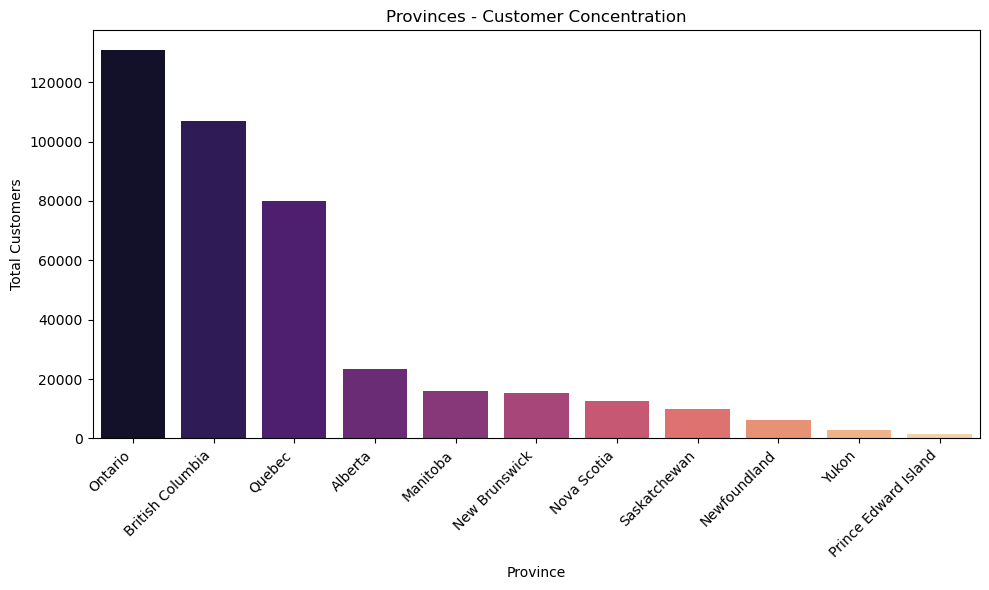

In [10]:


df_province = df_customer_clean['Province'].value_counts().reset_index()
df_province.columns = ['Province', 'Total_Customers']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_province.head(11),
    x='Province',
    y='Total_Customers',
    palette='magma'
)
plt.title('Provinces - Customer Concentration')
plt.ylabel('Total Customers')
plt.xlabel('Province')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. How does the average salary compare across different levels of education among clients?

* In the case of college, only one line appears because the value did not exist and was calculated using the average of the values above and below it. The line shows that average; there is no salary range. 

- Clear trend: the lower the level of education, the lower the salary.
- Largest difference: those with a PhD earn twice as much as those with a master’s degree. 


C:\Users\micae\AppData\Local\Temp\ipykernel_8384\2049524319.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


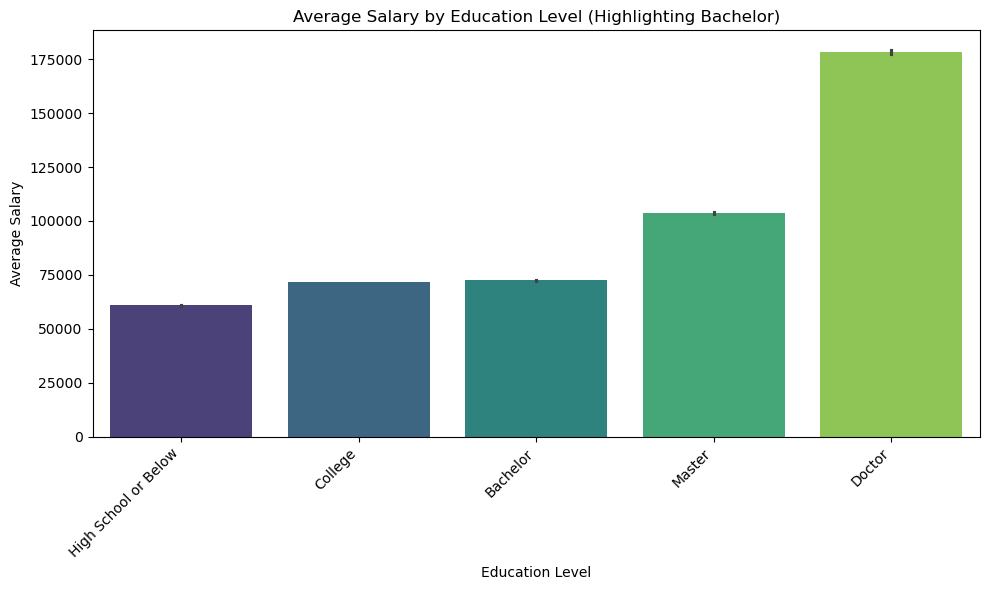

In [11]:
plt.figure(figsize=(10, 6))

df_ordered = df_customer_clean.groupby('Education')['Salary'].mean().reset_index()


df_ordered = df_ordered.sort_values(by='Salary')


education_order = df_ordered['Education'].tolist()


colours = palette=sns.color_palette("viridis", n_colors=len(df_customer_clean['Education'].unique()))


sns.barplot(
    data=df_customer_clean,
    x='Education',
    y='Salary',
    order=education_order,    
    estimator=np.mean,         
    palette=colours
)

plt.title('Average Salary by Education Level (Highlighting Bachelor)')
plt.ylabel('Average Salary')
plt.xlabel('Education Level')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

C:\Users\micae\AppData\Local\Temp\ipykernel_8384\2084847467.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


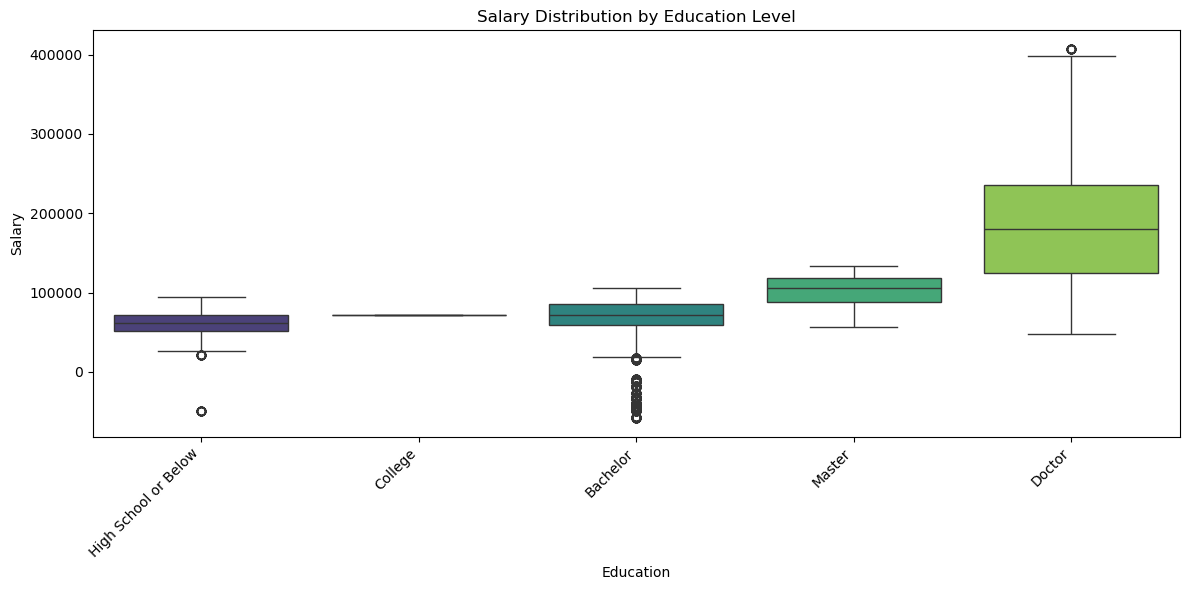

In [12]:
#Relación entre Salary y Education
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_customer_clean.sort_values('Education'), 
    x='Education', 
    y='Salary',
    palette=sns.color_palette("viridis", n_colors=len(df_customer_clean['Education'].unique())),
    order=education_order
)
plt.title('Salary Distribution by Education Level')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

### 5. What is the proportion of customers with different types of loyalty cards? 

Almost half of our customers are ‘Star’ members.
It is important to understand the card tiers to determine whether the loyalty programme requires effective incentives to encourage progression.






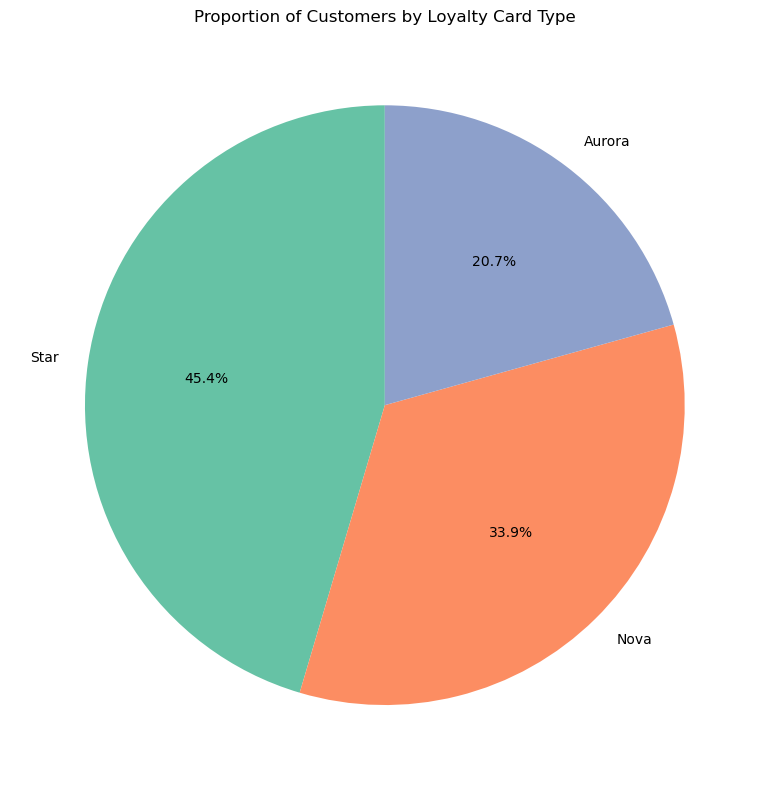

In [13]:


card_counts = df_customer_clean['Loyalty Card'].value_counts()


plt.figure(figsize=(8, 8))

plt.pie(
    card_counts, 
    labels=card_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,     
    colors=sns.color_palette("Set2")
)

plt.title('Proportion of Customers by Loyalty Card Type')
plt.tight_layout()
plt.show()

### 6. How are customers distributed according to their marital status and gender?

It can be seen that the majority of customers are married, followed by single people (half). 

Suggestion: Offer benefits for bringing a companion along on the trip. 
Or offer benefits for bringing someone in as a customer: sign them up for a membership card. The couple’s CLV is likely to be similar. 

For every X points accumulated, offer an incentive to travel with a companion or to bring someone else along. Focus campaigns on married couples. 



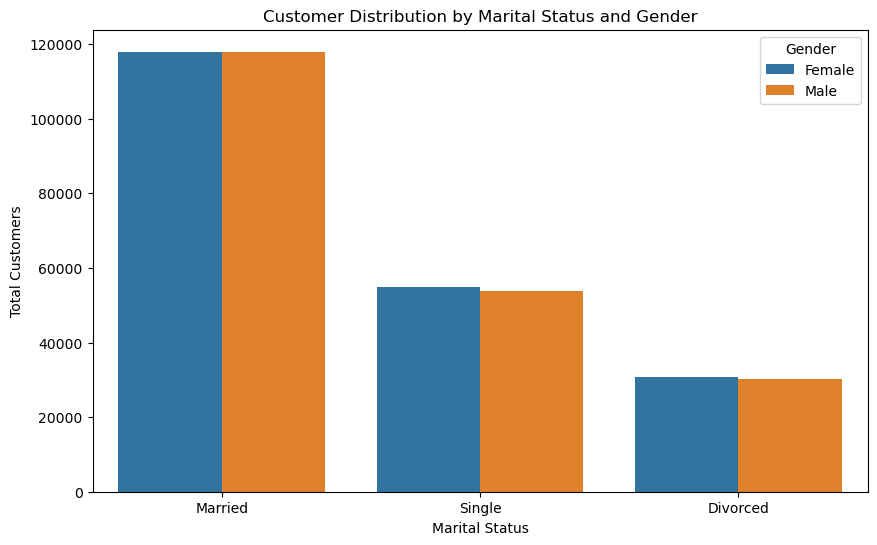

In [14]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_customer_clean,
    x='Marital Status', 
    hue='Gender',      
    palette='tab10', 
    order=df_customer_clean['Marital Status'].value_counts().index 
)

plt.title('Customer Distribution by Marital Status and Gender')
plt.xlabel('Marital Status')
plt.ylabel('Total Customers')
plt.legend(title='Gender')
plt.show()

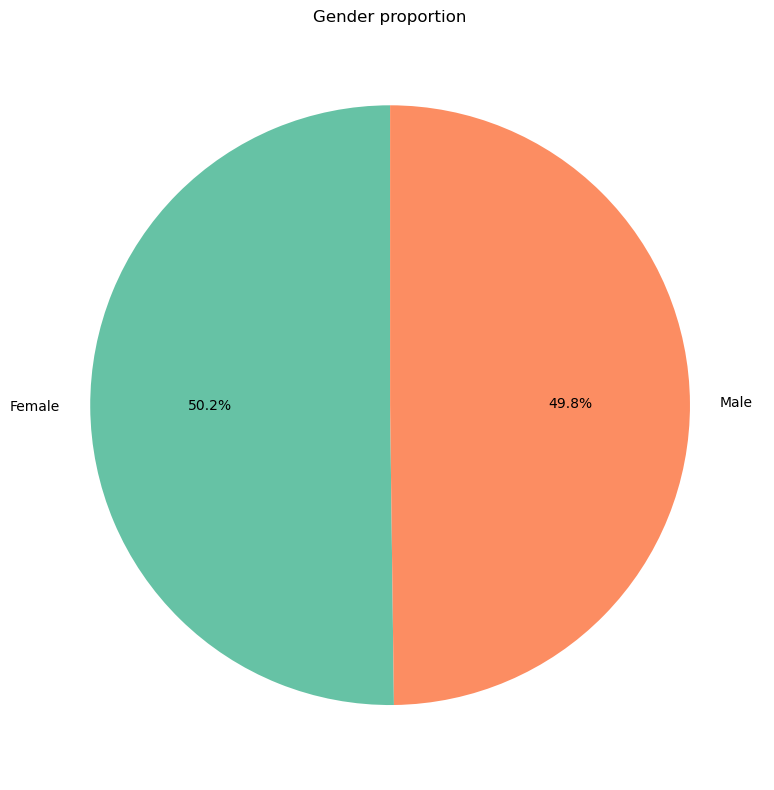

In [15]:
gender_counts = df_customer_clean['Gender'].value_counts()

# 2. Creación del Pie Chart
plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,     
    colors=sns.color_palette("Set2")
)

plt.title('Gender proportion')
plt.tight_layout()
plt.show()